# 03 — Feature Engineering
**Day 3, Part 1.** Goal: build the model-ready daily forecasting table from the cleaned SCADA data
(`data/interim/scada_wtg001_cleaned_2025.csv`, produced on Day 2).

**Framing decision, stated up front:** the work plan says "predict next-day generation." With
10-minute SCADA for a single turbine, we aggregate to **one row per day** and predict
**tomorrow's total generation (kWh)** from today's weather/generation context plus recent history.
This is the right grain for a demo — a 10-minute-ahead model is also possible later but isn't
what "next-day" means here.

No solar or separate demand dataset exists (confirmed Day 1), so this is a **wind generation
forecast only** — say so explicitly in the Day 4 model summary rather than implying more.

In [7]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.config_loader import load_config, interim_path, processed_path
from src.features.time_features import (
    add_time_features, add_rolling_features,
    build_daily_generation_table, add_daily_lag_and_target
)

cfg = load_config()


## 1. Load Day 2's cleaned SCADA table

In [8]:
scada = pd.read_csv(interim_path("scada_wtg001_cleaned_2025.csv", cfg), parse_dates=["timestamp"])
scada = scada.sort_values("timestamp").reset_index(drop=True)
print("Shape:", scada.shape)
scada[["timestamp", "wind_speed_mps", "active_power_kw", "energy_generated_kwh"]].head()



Shape: (52560, 38)


,timestamp,wind_speed_mps,active_power_kw,energy_generated_kwh
0,2025-01-01 00:00:00,8.05,699.30,116.55
1,2025-01-01 00:10:00,5.71,233.11,38.85
2,2025-01-01 00:20:00,9.01,1013.01,168.83
3,2025-01-01 00:30:00,9.43,1274.91,212.49
4,2025-01-01 00:40:00,4.30,77.36,12.89


## 2. Add time-of-day / seasonality features at 10-minute resolution
Useful for later (e.g. a 10-min-ahead model, or the copilot explaining diurnal patterns), even
though the daily model below aggregates past them.

In [9]:
scada = add_time_features(scada, timestamp_col="timestamp")
scada = add_rolling_features(scada, col="active_power_kw",
                              windows={"1h": 6, "24h": 144, "7d": 1008})
scada = add_rolling_features(scada, col="wind_speed_mps",
                              windows={"24h": 144})
scada[["timestamp", "hour_sin", "doy_sin", "active_power_kw_rolling_mean_24h"]].tail()



,timestamp,hour_sin,doy_sin,active_power_kw_rolling_mean_24h
52555,2025-12-31 23:10:00,-0.258819,-0.004301,829.745764
52556,2025-12-31 23:20:00,-0.258819,-0.004301,824.819792
52557,2025-12-31 23:30:00,-0.258819,-0.004301,819.445069
52558,2025-12-31 23:40:00,-0.258819,-0.004301,820.384167
52559,2025-12-31 23:50:00,-0.258819,-0.004301,820.194097


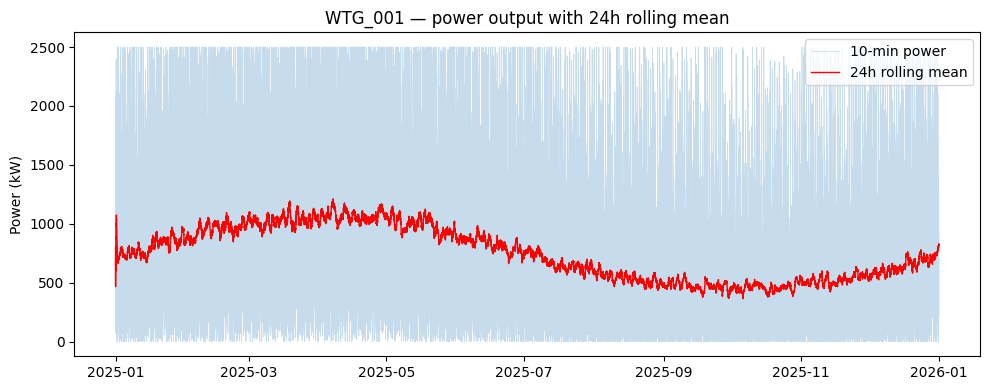

In [22]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(scada["timestamp"], scada["active_power_kw"], alpha=0.25, linewidth=.5, label="10-min power")
ax.plot(scada["timestamp"], scada["active_power_kw_rolling_mean_24h"], color="red", linewidth=1, label="24h rolling mean")
ax.set_ylabel("Power (kW)")
ax.set_title("WTG_001 — power output with 24h rolling mean")
ax.legend()
fig.tight_layout()
fig.savefig(PROJECT_ROOT / "reports/figures/day3_power_rolling_mean.png", dpi=150)
plt.show()


## 3. Aggregate to daily generation
This is the table the forecasting model actually trains on.

In [11]:
daily = build_daily_generation_table(scada, timestamp_col="timestamp", energy_col="energy_generated_kwh")
print("Daily rows:", daily.shape)
daily.head()


Daily rows: (365, 8)


,timestamp,generation_kwh,mean_wind_speed,max_wind_speed,mean_wind_direction,mean_ambient_temp,mean_air_density,availability_pct
0,2025-01-01,16616.40,7.424861,13.10,224.112500,27.075556,1.175231,0.986111
1,2025-01-02,17693.63,7.501806,12.63,226.001389,27.160625,1.173478,0.993056
2,2025-01-03,18622.27,7.576042,12.62,225.971528,27.082569,1.174704,0.993056
3,2025-01-04,17288.42,7.508681,13.84,226.188889,27.274236,1.174206,0.986111
4,2025-01-05,17057.86,7.358681,13.40,225.773611,27.171111,1.173990,1.000000


## 4. Add lag/rolling features and the next-day target
Every lag/rolling feature is shifted to only use information available before the day being predicted — the leakage-safety rule the work plan calls out explicitly.

In [12]:
daily = add_daily_lag_and_target(daily, target_horizon_days=1)
target_col = "target_next_1day_generation_kwh"

print("Rows before dropping NaN (from lag warm-up + last day with no target):", len(daily))
daily_model = daily.dropna().reset_index(drop=True)
print("Rows after:", len(daily_model))
daily_model.head()


Rows before dropping NaN (from lag warm-up + last day with no target): 365
Rows after: 334


,timestamp,generation_kwh,mean_wind_speed,max_wind_speed,mean_wind_direction,mean_ambient_temp,mean_air_density,availability_pct,day_of_year,month,...,is_weekend,doy_sin,doy_cos,gen_lag_1d,gen_lag_2d,gen_lag_7d,gen_rolling_mean_7d,gen_rolling_mean_30d,wind_rolling_mean_7d,target_next_1day_generation_kwh
0,2025-01-31,19785.77,7.886806,13.40,226.771528,28.989097,1.168024,1.000000,31,1,...,0,0.508356,0.861147,23137.15,20557.43,18782.50,20854.892857,19267.213333,8.035536,22331.33
1,2025-02-01,22331.33,8.274097,12.91,226.802083,28.987917,1.167699,1.000000,32,2,...,1,0.523094,0.852275,19785.77,23137.15,22324.02,20998.217143,19372.859000,8.044266,19768.18
2,2025-02-02,19768.18,7.928889,13.83,224.671528,28.951181,1.167232,0.993056,33,2,...,1,0.537677,0.843151,22331.33,19785.77,21309.45,20999.261429,19527.449000,8.055744,20239.38
3,2025-02-03,20239.38,7.876667,13.98,224.841667,29.112153,1.166890,1.000000,34,2,...,0,0.552101,0.833777,19768.18,22331.33,20378.53,20779.080000,19565.646000,8.034008,21002.29
4,2025-02-04,21002.29,8.034444,13.09,223.554861,28.914097,1.168085,0.986111,35,2,...,0,0.566362,0.824157,20239.38,19768.18,19495.17,20759.201429,19664.011333,8.026944,22421.14


## 5. Quick correlation check
Sanity-check that the features we built actually relate to the target before handing this to a model.

In [13]:
feature_cols = [c for c in daily_model.columns if c not in ["timestamp", "generation_kwh", target_col]]
corr = daily_model[feature_cols + [target_col]].corr()[target_col].drop(target_col).sort_values(key=abs, ascending=False)
corr


doy_sin                 0.982178
mean_ambient_temp       0.981374
mean_air_density       -0.979944
gen_rolling_mean_7d     0.977055
wind_rolling_mean_7d    0.976199
mean_wind_speed         0.968411
gen_lag_1d              0.966476
gen_lag_2d              0.965671
gen_lag_7d              0.957367
gen_rolling_mean_30d    0.948926
day_of_year            -0.831012
month                  -0.830507
max_wind_speed          0.682613
doy_cos                -0.059430
availability_pct       -0.027681
mean_wind_direction     0.016631
day_of_week            -0.014428
is_weekend             -0.010687
Name: target_next_1day_generation_kwh, dtype: float64

## 6. Save the processed feature table

In [14]:
out_path = processed_path("daily_generation_features.csv", cfg)
out_path.parent.mkdir(parents=True, exist_ok=True)
daily_model.to_csv(out_path, index=False)
print("Saved:", out_path, daily_model.shape)


Saved: C:\Users\ashok\Downloads\wind-energy-ai-platform\wind-energy-ai-platform\data\processed\daily_generation_features.csv (334, 21)


---
## Checkpoint

`data/processed/daily_generation_features.csv` is ready: {n} daily rows, {k} features, target =
next day's total generation in kWh. Strongest correlated features should be wind-speed related
and yesterday's generation (`gen_lag_1d`) — if they aren't, something in the feature build is off,
check before moving to the next notebook.

Next: `04_forecasting_baseline_model.ipynb` — chronological split, XGBoost/LightGBM baseline,
MAE/RMSE/MAPE evaluation.